<a href="https://colab.research.google.com/github/noobylub/Computational-Linguistic/blob/master/ResearchComputationalLinguisticWeek_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LELA60342 Week 6 - Evaluation: Receiver Operating Characteristic (ROC) Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc
import pandas as pd

In [9]:
## Create simulated data
#np.random.seed(10)
w1_center = (2, 4)
w2_center = (4, 2)
batch_size=1000

x = np.zeros((batch_size, 2))
y = np.zeros(batch_size)
for i in range(batch_size):
    if np.random.random() > 0.5:
        x[i] = np.random.normal(loc=w1_center,scale=10)
    else:
        x[i] = np.random.normal(loc=w2_center,scale=10)
        y[i] = 1




In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train, y_train)

LogisticRegression()

In [11]:
precision_recall_fscore_support(y_test,logisticRegr.predict(x_test),average="macro")[2]

0.5584102769971899

<Axes: ylabel='Density'>

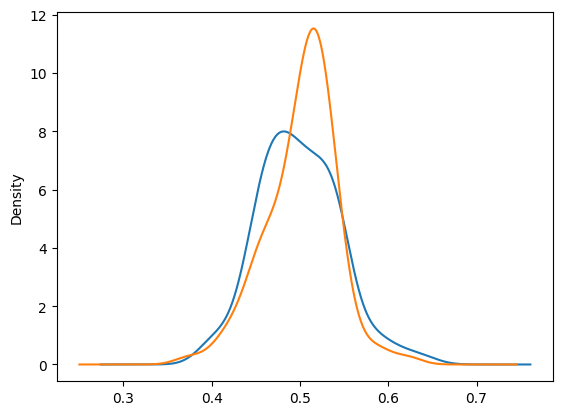

In [12]:
preds_and_labels=pd.DataFrame({"p" : logisticRegr.predict_proba(x_test).T[1], "lab" : y_test})
preds_and_labels[preds_and_labels["lab"] == 0]["p"].plot(kind="density")
preds_and_labels[preds_and_labels["lab"] == 1]["p"].plot(kind="density")

In [13]:
# THE ROC curve
fpr, tpr, thresholds = roc_curve(y_test,logisticRegr.predict_proba(x_test).T[1])

In [14]:
thresholds

array([       inf, 0.63934015, 0.6218049 , 0.60087972, 0.58592248,
       0.57922693, 0.56123252, 0.5523126 , 0.55192347, 0.55028308,
       0.54965349, 0.54807477, 0.54760516, 0.54147448, 0.53877351,
       0.538104  , 0.53781213, 0.53753492, 0.5367642 , 0.53672135,
       0.53570477, 0.53439307, 0.53340214, 0.53272126, 0.53205993,
       0.53096298, 0.53007342, 0.52883026, 0.52705128, 0.52673167,
       0.52249029, 0.52170002, 0.52097233, 0.52021549, 0.51902085,
       0.51857239, 0.51457616, 0.51410797, 0.51275355, 0.51120107,
       0.50861879, 0.50850092, 0.50820073, 0.50807124, 0.50760038,
       0.50666682, 0.50567022, 0.50548912, 0.50523985, 0.50435662,
       0.50410626, 0.50271633, 0.50145104, 0.49841781, 0.49676098,
       0.49558666, 0.49034623, 0.48995778, 0.48948731, 0.48851336,
       0.48834865, 0.4879457 , 0.48734984, 0.48538279, 0.48248076,
       0.48016785, 0.47831523, 0.47791938, 0.47605813, 0.47376717,
       0.47338484, 0.47318218, 0.47282545, 0.46764076, 0.46732

In [16]:
i=5

print(fpr[i],tpr[i],thresholds[i])

0.061855670103092786 0.02912621359223301 0.5792269279063769


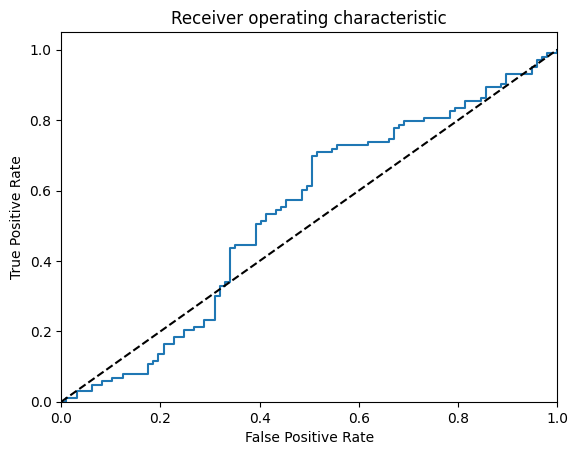

In [17]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()
# We want to know the area above the straight line

# Area under the curve

In [18]:
auc(fpr, tpr)

np.float64(0.5355820238214393)

# A different dataset

In [ ]:
import numpy as np
## Create simulated data
#np.random.seed(10)
w1_center = (2, 8)
w2_center = (8, 2)
batch_size=1000

x = np.zeros((batch_size, 2))
y = np.zeros(batch_size)
for i in range(batch_size):
    if np.random.random() > 0.5:
        x[i] = np.random.normal(loc=w1_center,scale=10)
    else:
        x[i] = np.random.normal(loc=w2_center,scale=10)
        y[i] = 1

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=0.2, random_state=10)
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train2, y_train2)

LogisticRegression()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test2,logisticRegr.predict(x_test2),average="macro")[2]

0.6598639455782312

In [ ]:
preds_and_labels2=pd.DataFrame({"p" : logisticRegr.predict_proba(x_test2).T[1], "lab" : y_test2})

<Axes: ylabel='Density'>

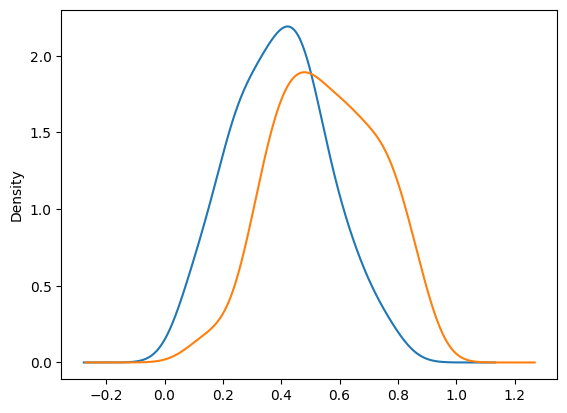

In [ ]:
preds_and_labels2[preds_and_labels2["lab"] == 0]["p"].plot(kind="density")
preds_and_labels2[preds_and_labels2["lab"] == 1]["p"].plot(kind="density")


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test2,logisticRegr.predict_proba(x_test2).T[1])

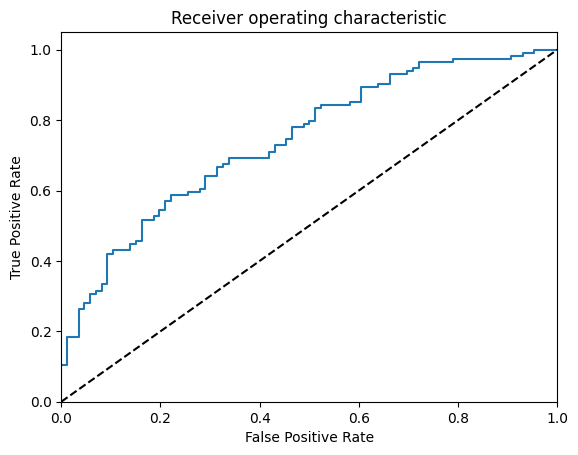

In [ ]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()

# Area under the curve

In [ ]:
auc(fpr, tpr)

np.float64(0.7412280701754385)

### Task 1: Use Bootstrapping to put a 95% confidence interval around the AUC value for this classifier (see the sheet from week 5)

In [ ]:
def draw_bootstrap_sample(data):
      n=len(data[0])
      indices = random.choices(range(n),k=n)
      return((data[0][indices],data[1][indices]))

In [ ]:
# Using bootstrapping
from sklearn.utils import resample
n_iterations = 1000


### Task 2: Use 5-fold cross validation to put an interval around the AUC value for this classifier (see the sheet from week 5)